# SINDy-SHRED: Synthetic Data Example

This notebook demonstrates SINDy-SHRED on a synthetic toy dataset using the `SINDySHRED` class. The class handles data preprocessing, model training, and post-hoc SINDy discovery automatically.

## Overview

**SHRED** (SHallow REcurrent Decoder) models combine a recurrent layer (GRU) with a shallow decoder network to reconstruct high-dimensional spatio-temporal fields from sensor measurements.

**SINDy-SHRED** extends this by integrating Sparse Identification of Nonlinear Dynamics (SINDy) to learn interpretable governing equations:

$$\dot{z} = \Theta(z) \xi$$

## Synthetic Data

The synthetic data uses the **FitzHugh-Nagumo Model** with spatially delayed copies:

$$\dot{v} = v - \frac{1}{3}v^3 - w + I_{ext}$$
$$\dot{w} = \frac{1}{\tau}(v + a - bw)$$

## Notebook Structure

1. Setup and Imports
2. Data Generation
3. Model Configuration and Training
4. SINDy Discovery
5. Evaluation
6. Save Results

## 1. Setup and Imports

In [1]:
import copy
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from scipy.integrate import solve_ivp

import plotting

# Local modules
from sindy_shred import SINDySHRED

warnings.filterwarnings("ignore")

# Create results directory
RESULTS_DIR = "results/synthetic_data"
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Results will be saved to: {RESULTS_DIR}")

Results will be saved to: results/synthetic_data


### Device and Seed Configuration

In [2]:
# Device selection
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Using device: {device}")

# Set seeds for reproducibility
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if device == "cuda":
    torch.cuda.manual_seed(SEED)

Using device: mps


### Plotting Configuration

In [3]:
sns.set_context("paper")
sns.set_style("whitegrid")

pcolor_kwargs = {
    "vmin": -3,
    "vmax": 3,
    "cmap": "RdBu_r",
    "rasterized": True,
}

## 2. Data Generation

Generate synthetic spatio-temporal data from the FitzHugh-Nagumo model with spatially delayed copies.

### Define Dynamical System

In [4]:
# def rhs_FNM(t, x, tau, a, b, Iext):
#     """FitzHugh-Nagumo Model.

#     Parameters
#     ----------
#     t : float
#         Time (unused, for ODE solver interface).
#     x : array-like
#         State vector [v, w].
#     tau : float
#         Time constant.
#     a, b : float
#         Model parameters.
#     Iext : float
#         External input current.

#     Returns
#     -------
#     dx : array-like
#         Time derivatives [dv/dt, dw/dt].
#     """
#     v, w = x
#     vdot = v - (v**3) / 3 - w + Iext
#     wdot = (1 / tau) * (v + a - b * w)
#     return np.array([vdot, wdot])

In [5]:
# Time integration parameters
T = 64
dt_solve = 0.0001 * 8
t_solution = np.arange(0, T, dt_solve)

# FitzHugh-Nagumo parameters
x0 = np.array([-1.110, -0.125])
tau1 = 2
a = 0.7
b = 0.8
Iext = 0.65

# Solve the ODE
solution_fn = solve_ivp(rhs_FNM, [0, T], x0, t_eval=t_solution, args=(tau1, a, b, Iext))

print(f"FitzHugh-Nagumo solution shape: {solution_fn.y.shape}")

### Generate Data

In [6]:
def rhs_vdp(t, z, tau, mu):
    s, u = z

    ds = u
    # du = (1 / tau) * (-2 * eta * u - s - epsilon * s**3)
    du = (1 / tau) * (mu * (1 - s**2) * u - s)
    return np.array([ds, du])

In [7]:
# Time integration parameters
T = 70
dt_solve = 0.0001
t_solution = np.arange(0, T, dt_solve)

# FitzHugh-Nagumo parameters
# x0 = np.array([0, 2])
x0 = np.array([-1, 1])
tau = 3
mu = 2

# Solve the ODE
solution_vdp = solve_ivp(rhs_vdp, [0, T], x0, t_eval=t_solution, args=(tau, mu))


print(f"Van der Pol solution shape: {solution_vdp.y.shape}")

# Create spatially delayed copies
num_space_dims = 40
delays = np.linspace(0, 3, num_space_dims)  # delays in time units
# uv_spatial = np.zeros((len(t_solution), 2 * num_space_dims))

s_spatial = np.zeros((len(t_solution), num_space_dims))

s_obs = solution_vdp.y[0, :]  # Extract position observations

# for i in range(num_space_dims):
#     delay_steps = int(delays[i] / dt_solve)
#     if delay_steps == 0:
#         uv_spatial[:, 2 * i : 2 * i + 2] = solution_vdp.y.T
#     else:
#         # Pad with initial condition and shift
#         uv_spatial[:, 2 * i : 2 * i + 2] = np.vstack(
#             [np.tile(x0, (delay_steps, 1)), solution_vdp.y.T[:-delay_steps, :]]
#         )

for i in range(num_space_dims):
    delay_steps = int(delays[i] / dt_solve)
    if delay_steps == 0:
        s_spatial[:, i] = s_obs
    else:
        # Pad with initial condition and shift
        s_spatial[:, i] = np.concatenate([
            np.full(delay_steps, x0[0]),  # Use initial position
            s_obs[:-delay_steps]
        ])

# Subsample for computational efficiency
substep = 50 * 8
s_spatial = s_spatial[0::substep, :]
# uv_spatial = uv_spatial[0::substep, :]
t_solution = t_solution[0::substep]

# Chop off the first part of the solution when the system is non-stationary.
t_solution = t_solution[150:]
s_spatial = s_spatial[150:, :]
# uv_spatial = uv_spatial[150:, :]


time = t_solution
dt_data = time[1] - time[0]

# Get dimensions
n_space_dims = s_spatial.shape[1]
n_time = s_spatial.shape[0]

# n_space_dims = uv_spatial.shape[1]
# n_time = uv_spatial.shape[0]

# Final data matrix (space x time for visualization)
# data_original = uv_spatial.T
data_original = s_spatial.T
space_dim = np.arange(n_space_dims)

print(f"Data shape (space x time): {data_original.shape}")
print(f"Time step: {dt_data:.6f}")
print(f"Number of time samples: {n_time}")
print(f"Spatial dimension: {n_space_dims}")

Van der Pol solution shape: (2, 700000)
Data shape (space x time): (40, 1600)
Time step: 0.040000
Number of time samples: 1600
Spatial dimension: 40


### Visualize Generated Data

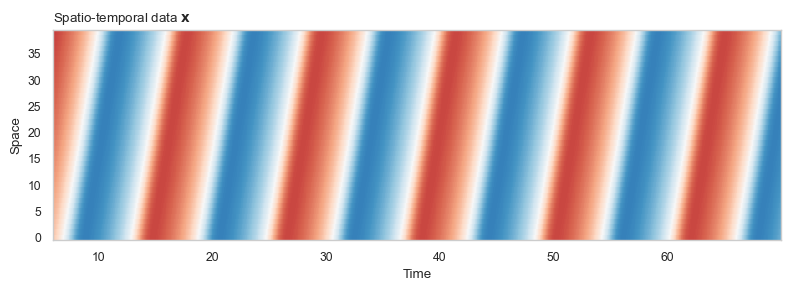

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(8, 3))

ax.pcolormesh(time, space_dim, data_original, **pcolor_kwargs)
ax.set_title(r"Spatio-temporal data $\mathbf{x}$", loc="left")
ax.set_ylabel("Space")
ax.set_xlabel("Time")

fig.tight_layout()

# Save the data visualization plot
# fig.savefig(f"{RESULTS_DIR}/data_original.pdf", bbox_inches="tight", dpi=300)
# fig.savefig(f"{RESULTS_DIR}/data_original.png", bbox_inches="tight", dpi=300)
# print(f"Saved data plot to {RESULTS_DIR}/data_original.pdf")

plt.show()

## 3. Model Configuration and Training

Configure the SINDy-SHRED model using the `SINDySHRED` class.

### Data Configuration

In [24]:
# Sensor configuration (fixed for reproducibility)
sensor_locations = np.array([5, 14, 7])
num_sensors = len(sensor_locations)

# Model hyperparameters
latent_dim = 2
poly_order = 3

# Data split configuration
lags = 120
train_length = 750 // 4
validate_length = 0

# Prepare data (transpose to time x space, subsample)
load_X = copy.deepcopy(data_original)
load_X = load_X.T[::4]  # Subsample
dt = dt_data * 4
lags = lags // 4
t_plot = time[::4]

# SINDy threshold
threshold = 0.0

print(f"Data shape after preprocessing: {load_X.shape}")
print(f"Number of sensors: {num_sensors}")
print(f"Latent dimension: {latent_dim}")
print(f"Trajectory length (lags): {lags}")
print(f"Training length: {train_length}")
print(f"Time step: {dt:.6f}")

Data shape after preprocessing: (400, 40)
Number of sensors: 3
Latent dimension: 2
Trajectory length (lags): 30
Training length: 187
Time step: 0.160000


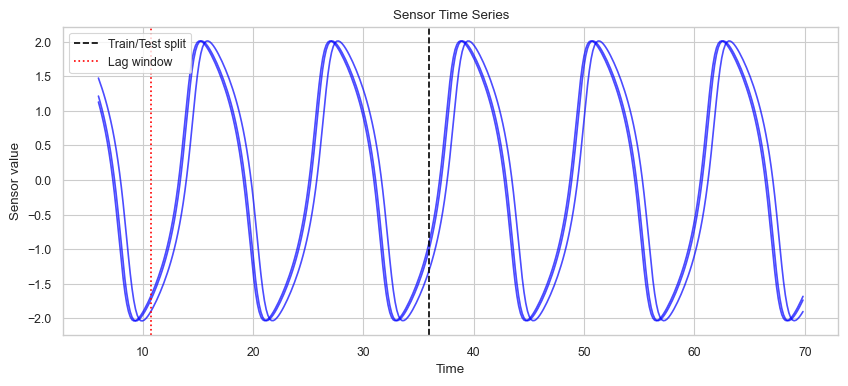

In [25]:
# Visualize sensor time series
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_plot, load_X[:, sensor_locations], color="b", alpha=0.7)
ax.axvline(t_plot[train_length], color="k", linestyle="--", label="Train/Test split")
ax.axvline(t_plot[lags], color="r", linestyle=":", label="Lag window")
ax.set_xlabel("Time")
ax.set_ylabel("Sensor value")
ax.set_title("Sensor Time Series")
ax.legend()
plt.show()

### Initialize and Train Model

The `SINDySHRED` class handles data preprocessing and model training.

In [26]:
# Initialize the model
model = SINDySHRED(
    latent_dim=latent_dim,
    poly_order=poly_order,
    ode_order=1,  # 1st order ODE: z' = f(z), 2nd order ODE:
    num_epochs=600,
    verbose=True,
    device=device,
    threshold=threshold,
)

# Fit the model
model.fit(
    num_sensors, dt, load_X, lags, train_length, validate_length, sensor_locations
)

1 : tensor(0.2818, device='mps:0', grad_fn=<AddBackward0>)
2 : tensor(0.2116, device='mps:0', grad_fn=<AddBackward0>)
3 : tensor(0.2373, device='mps:0', grad_fn=<AddBackward0>)
4 : tensor(0.2490, device='mps:0', grad_fn=<AddBackward0>)
5 : tensor(0.2143, device='mps:0', grad_fn=<AddBackward0>)
6 : tensor(0.2004, device='mps:0', grad_fn=<AddBackward0>)
7 : tensor(0.1982, device='mps:0', grad_fn=<AddBackward0>)
8 : tensor(0.1925, device='mps:0', grad_fn=<AddBackward0>)
9 : tensor(0.1919, device='mps:0', grad_fn=<AddBackward0>)
10 : tensor(0.1949, device='mps:0', grad_fn=<AddBackward0>)
11 : tensor(0.1984, device='mps:0', grad_fn=<AddBackward0>)
12 : tensor(0.2033, device='mps:0', grad_fn=<AddBackward0>)
13 : tensor(0.1997, device='mps:0', grad_fn=<AddBackward0>)
14 : tensor(0.1914, device='mps:0', grad_fn=<AddBackward0>)
15 : tensor(0.1873, device='mps:0', grad_fn=<AddBackward0>)
16 : tensor(0.1844, device='mps:0', grad_fn=<AddBackward0>)
17 : tensor(0.1804, device='mps:0', grad_fn=<AddB

## 4. SINDy Discovery

Discover sparse governing equations from the learned latent space.

SINDy-derived dynamical equation (1st order):

(x0)' = 0.432 x0 + -0.723 x1
(x1)' = 0.658 x0 + -0.436 x1


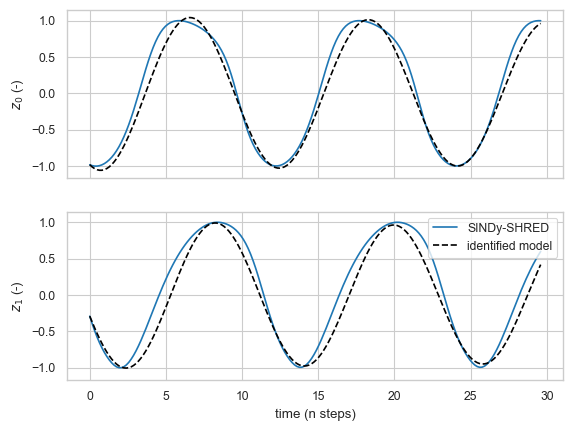

SINDy-derived dynamical equation (1st order):

(x0)' = 0.329 x0 + -0.849 x1 + 0.385 x0^2 x1
(x1)' = 0.661 x0 + -0.435 x1 + -0.060 x0^2


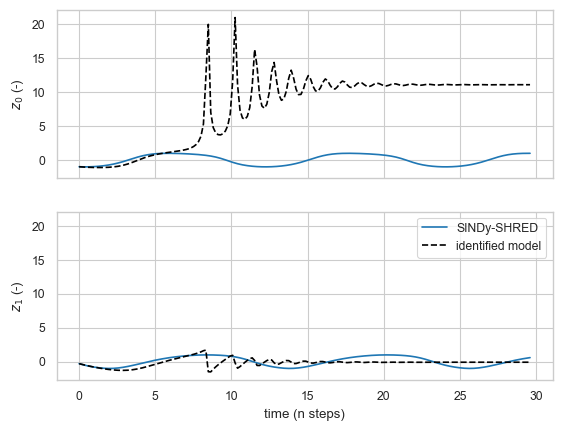

SINDy-derived dynamical equation (1st order):

(x0)' = 0.068 1 + 0.326 x0 + -0.855 x1 + 0.400 x0 x1^2
(x1)' = 0.695 x0 + -0.472 x1 + -0.305 x0 x1 + 0.238 x1^2


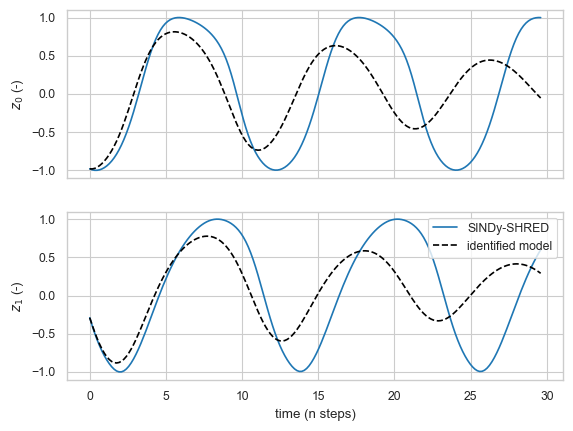

SINDy-derived dynamical equation (1st order):

(x0)' = 0.055 1 + 0.602 x0 + -0.916 x1 + -0.413 x0^3 + 0.576 x0^2 x1
(x1)' = 0.155 1 + 0.540 x0 + -0.425 x1 + -0.258 x0^2 + 0.147 x0^3


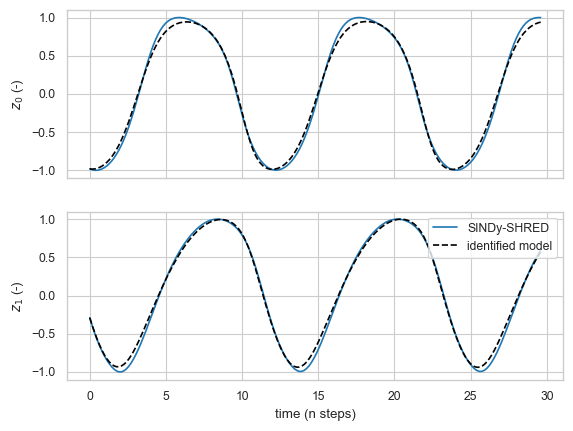

SINDy-derived dynamical equation (1st order):

(x0)' = 0.080 1 + 0.600 x0 + -0.916 x1 + -0.073 x0 x1 + -0.402 x0^3 + 0.564 x0^2 x1
(x1)' = 0.154 1 + 0.570 x0 + -0.408 x1 + -0.257 x0^2 + 0.125 x0^3 + -0.051 x0 x1^2


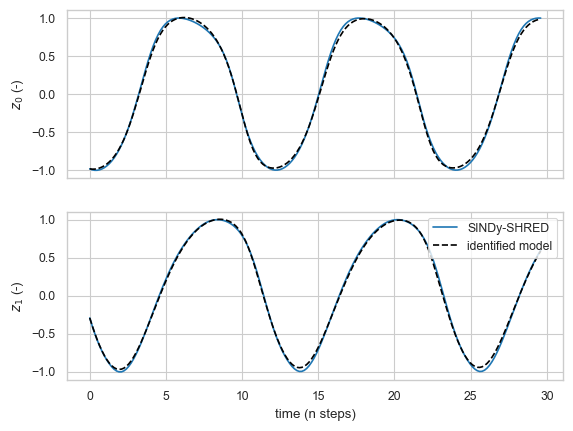

SINDy-derived dynamical equation (1st order):

(x0)' = 0.654 x0 + -0.944 x1 + 0.090 x0^2 + -0.206 x0 x1 + 0.146 x1^2 + -0.449 x0^3 + 0.581 x0^2 x1
(x1)' = 0.136 1 + 0.452 x0 + -0.562 x1 + -0.231 x0^2 + 0.303 x0^3 + -0.133 x0 x1^2 + 0.241 x1^3


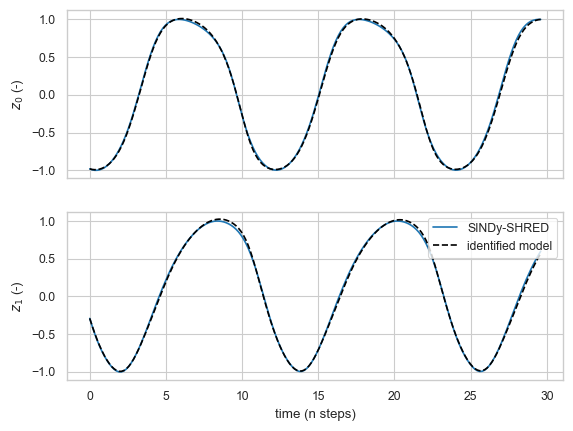

SINDy-derived dynamical equation (1st order):

(x0)' = -0.274 1 + 0.808 x0 + -1.029 x1 + 0.449 x0^2 + -0.613 x0 x1 + 0.547 x1^2 + -0.583 x0^3 + 0.626 x0^2 x1
(x1)' = 0.132 1 + 0.420 x0 + -0.601 x1 + -0.210 x0^2 + -0.028 x0 x1 + 0.347 x0^3 + -0.141 x0 x1^2 + 0.294 x1^3
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1083518700722D+02   r2 =  0.8006841335826D-15
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1083518700722D+02   r2 =  0.8006841335826D-15
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1083518700722D+02   r2 =  0.8006841335826D-15
 lsoda--

capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.


ValueError: Input X contains infinity or a value too large for dtype('float64').

In [56]:
os.chdir("/Users/karllapo/Library/CloudStorage/Dropbox/ESPRIT/proj/notebooks/mr-SHRED/mr-SHRED/mr-SHRED")
from sindy_utils import MIOSR

os.chdir("/Users/karllapo/Library/CloudStorage/Dropbox/ESPRIT/proj/notebooks/sindy-shred/sindy-shred/")
import miosr_utils

order = poly_order * latent_dim
for n in range(latent_dim, order * 2):
    group_sparsity = np.ones(latent_dim) * n
# group_sparsity = np.append(group_sparsity, np.ones(latent_dim) * order)

    optimizer_kwargs = {"group_sparsity": group_sparsity} # "alpha": 0.05, 
    optimizer = MIOSR

    miosr_utils.sindy_identify(model, optimizer=optimizer, optimizer_kwargs=optimizer_kwargs)

SINDy-derived dynamical equation (1st order):

(x0)' = 0.080 1 + 0.600 x0 + -0.916 x1 + -0.073 x0 x1 + -0.402 x0^3 + 0.564 x0^2 x1
(x1)' = 0.154 1 + 0.570 x0 + -0.408 x1 + -0.257 x0^2 + 0.125 x0^3 + -0.051 x0 x1^2


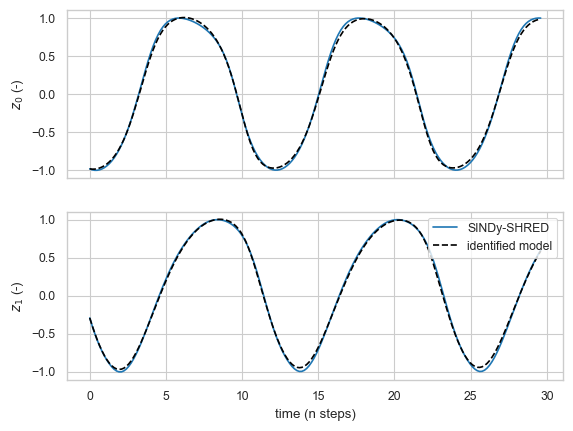

In [53]:
miosr_utils.sindy_identify(model, optimizer=optimizer, optimizer_kwargs=optimizer_kwargs)

SINDy-derived dynamical equation (1st order):

(x0)' = -0.284 1 + 0.823 x0 + -1.235 x1 + 0.445 x0^2 + -0.556 x0 x1 + 0.511 x1^2 + -0.587 x0^3 + 0.892 x0^2 x1 + -0.339 x0 x1^2 + 0.313 x1^3
(x1)' = 0.117 1 + 0.598 x0 + -0.734 x1 + -0.227 x0^2 + 0.039 x0 x1 + -0.022 x1^2 + 0.116 x0^3 + 0.406 x0^2 x1 + -0.565 x0 x1^2 + 0.484 x1^3


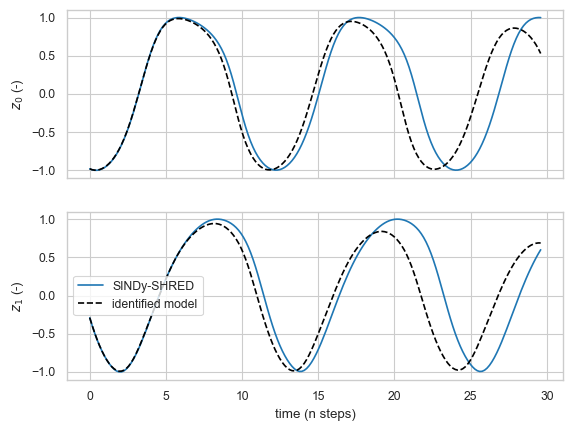

In [48]:
# Perform SINDy identification with automatic plot saving
model.sindy_identify(
    threshold=0., plot_result=True)#, save_path=f"{RESULTS_DIR}/latent_comparison"
# )
# print(f"Saved latent comparison plot to {RESULTS_DIR}/latent_comparison.png")

In [44]:
# import pysindy as ps

# sindy_ode = ps.SINDy(
#     optimizer=optimizer(**optimizer_kwargs),
#     differentiation_method=ps.differentiation.FiniteDifference(),
#     feature_library=ps.PolynomialLibrary(degree=model._poly_order),
# )
# sindy_ode.fit(solution_vdp.y.T[:len(time) * substep // 2, 0], t=model._dt, x_dot=solution_vdp.y.T[:len(time) * substep // 2, 1])

### Auto-Tune Threshold (Adaptive/Nonparametric)

Alternatively, use `auto_tune_threshold()` to automatically determine the best threshold.
By default it uses a nonparametric approach:
1. First computes the least-squares solution (threshold=0)
2. Uses `scale_factor * max(|coefficients|)` as the max threshold
3. Tests `n_thresholds` evenly spaced values and picks the best stable model

0.051666666666666666

In [62]:
# os.chdir("/Users/karllapo/Library/CloudStorage/Dropbox/ESPRIT/proj/notebooks/mr-SHRED/mr-SHRED/mr-SHRED")
# from sindy_utils import MIOSR

# order = 6
# group_sparsity = np.ones(latent_dim) * order

# optimizer_kwargs = {"alpha": 0.05, "group_sparsity": group_sparsity}
# optimizer = MIOSR

optimizer_kwargs = None
optimizer = None

# Auto-tune threshold using nonparametric approach
# This computes least-squares solution first, then determines threshold range adaptively
best_threshold, tune_results = model.auto_tune_threshold(
    adaptive=True,  # Use nonparametric approach (default)
    scale_factor=0.02 / 1.2,  # Max threshold = 0.3 * max(|coefficients|)
    n_thresholds=5,  # Test 10 evenly spaced thresholds
    metric="sparsity_stable",  # Pick sparsest stable model
    verbose=True,
    optimizer=optimizer,
    optimizer_kwargs=optimizer_kwargs
)

print(f"\nBest threshold: {best_threshold:.4f}")
print(f"Tested thresholds: {tune_results['thresholds']}")
print(f"Sparsity at each: {tune_results['sparsity']}")
print(f"Stability at each: {tune_results['stable']}")

Computing least-squares solution to determine threshold range...
Max |coefficient|: 1.2346
Max threshold (scale_factor=0.016666666666666666): 0.0206
Testing 5 thresholds: [0.         0.00514403 0.01028806 0.01543208 0.02057611]
Testing threshold=0.000... sparsity=20, stable, MSE=1.2020e-01
Testing threshold=0.005... sparsity=20, stable, MSE=1.2020e-01
Testing threshold=0.010... sparsity=20, stable, MSE=1.2020e-01
Testing threshold=0.015... sparsity=20, stable, MSE=1.2020e-01
Testing threshold=0.021... sparsity=19, stable, MSE=2.8615e-02

Best threshold: 0.021 (sparsity=19, MSE=2.8615e-02)
SINDy-derived dynamical equation (1st order):

(x0)' = -0.284 1 + 0.823 x0 + -1.235 x1 + 0.445 x0^2 + -0.556 x0 x1 + 0.511 x1^2 + -0.587 x0^3 + 0.892 x0^2 x1 + -0.339 x0 x1^2 + 0.313 x1^3
(x1)' = 0.018 1 + 0.443 x0 + -0.668 x1 + -0.056 x0^2 + -0.201 x0 x1 + 0.165 x1^2 + 0.348 x0^3 + -0.133 x0 x1^2 + 0.342 x1^3

Best threshold: 0.0206
Tested thresholds: [0.         0.00514403 0.01028806 0.01543208 0.02

### True Governing Equations

For reference, the true governing equations are:

**FitzHugh-Nagumo Model:**
$$\dot{v} = v - \frac{1}{3}v^3 - w + 0.65$$
$$\dot{w} = \frac{1}{\tau}(v + 0.7 - 0.8w)$$

with time constant $\tau = 2$.

We recover a model that resembles the original model. A more accurate model for sensor reconstruction and prediction can be achieved using a lower threshold, but this model would admit additional governing terms that are not present in the original model and may represent an overfit. For this reason, the criterion weigh the information gained against the number of parameters required. Depending on your use case you may find different criteria important and one should weigh these trade-offs.

## 5. Evaluation

Evaluate reconstruction performance on the test set.

In [34]:
# Compute test reconstruction error using new API
test_recons = model.sensor_recon(data_type="test", return_scaled=False)
test_ground_truth = model._scaler.inverse_transform(
    model._test_data.Y.detach().cpu().numpy()
)

relative_error = model.relative_error(test_recons, test_ground_truth)
print(f"Test set relative reconstruction error: {relative_error:.4f}")

Test set relative reconstruction error: 0.0666


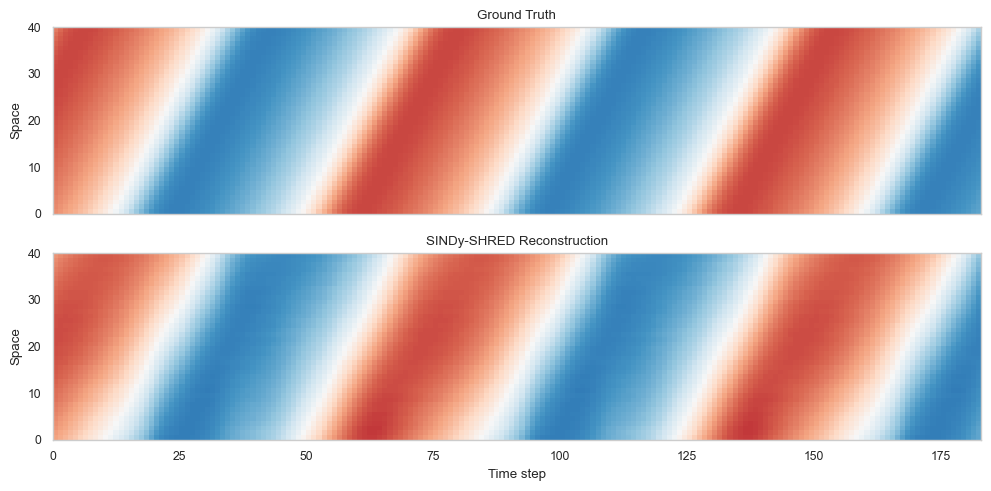

In [35]:
# Visualize reconstruction
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

ax = axes[0]
ax.pcolormesh(test_ground_truth.T, **pcolor_kwargs)
ax.set_title("Ground Truth")
ax.set_ylabel("Space")

ax = axes[1]
ax.pcolormesh(test_recons.T, **pcolor_kwargs)
ax.set_title("SINDy-SHRED Reconstruction")
ax.set_ylabel("Space")
ax.set_xlabel("Time step")

fig.tight_layout()

# # Save the reconstruction comparison plot
# fig.savefig(
#     f"{RESULTS_DIR}/reconstruction_comparison.pdf", bbox_inches="tight", dpi=300
# )
# fig.savefig(
#     f"{RESULTS_DIR}/reconstruction_comparison.png", bbox_inches="tight", dpi=300
# )
# print(
#     f"Saved reconstruction comparison plot to {RESULTS_DIR}/reconstruction_comparison.pdf"
# )

plt.show()

### Sensor-Level Predictions

Compare real vs predicted at individual spatial locations (sensors).

The **first approach** illustrates the overall work flow: 

- Predict the latent space by integrating the identified model forward in time. Initial condition is the last value of the training split's latent space trajectory.
- Pass the latent space trajectories through the shallow decoder in order to map to the higher dimensional space.
- Transform the higher dimensional data back to the original space.

This approach can also be used to predict other time periods.

The **second approach** combines all of the substeps from the first approach using a helper function.

SINDy prediction shape: (183, 2)
Decoded physical shape: (183, 40)


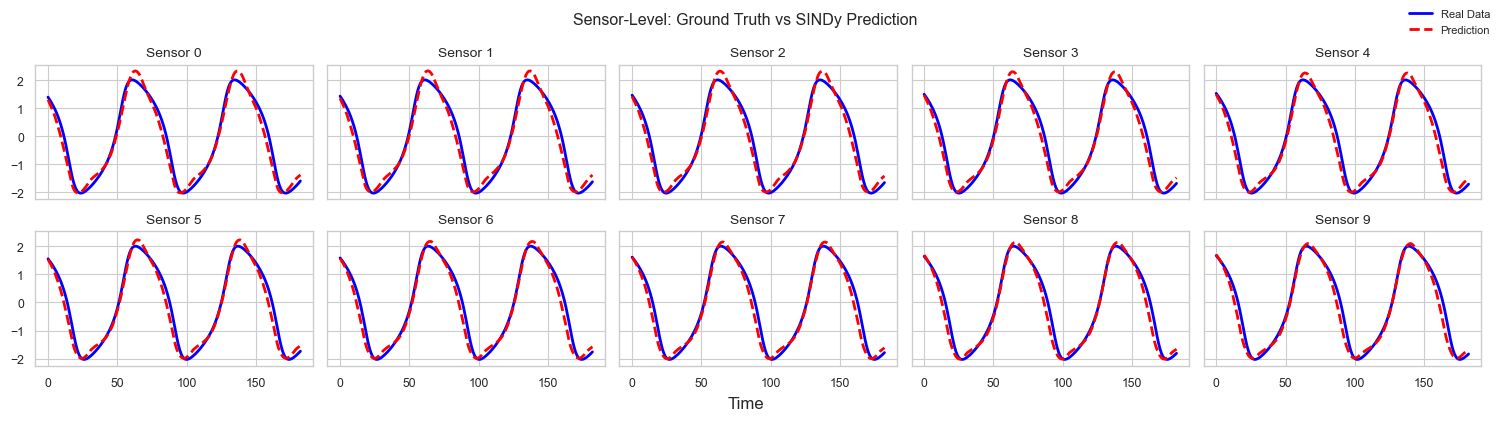

In [36]:
# 1st approach: Predict latent trajectories using SINDy model and decode to physical space
x_predict = model.predict_latent(split="train", init_from="last")  # SINDy prediction in latent space
sindy_physical = model.decode_to_physical(x_predict)  # Decode to physical space
sindy_physical = model._scaler.inverse_transform(sindy_physical)  # Unscale

# 2nd approach: Directly forecast from the last training point.
sindy_physical = model.forecast(return_scaled=False)

print(f"SINDy prediction shape: {x_predict.shape}")
print(f"Decoded physical shape: {sindy_physical.shape}")

# Plot sensor-level comparisons: Ground Truth vs SINDy Prediction
fig, axes = plotting.plot_sensor_predictions(
    test_ground_truth,
    sindy_physical[: len(test_ground_truth)],
    sensor_locations=np.arange(n_space_dims),  # All spatial dims
    rows=2,
    cols=5,
    # save_path=f"{RESULTS_DIR}/sensor_predictions_grid.pdf",
)
fig.suptitle("Sensor-Level: Ground Truth vs SINDy Prediction")
fig.tight_layout()
# print(f"Saved sensor predictions plot to {RESULTS_DIR}/sensor_predictions_grid.pdf")
plt.show()

## Summary

This notebook demonstrated SINDy-SHRED on synthetic FitzHugh-Nagumo data:

1. Generated toy data from FitzHugh-Nagumo model with spatial delays
2. Used the `SINDySHRED` class for streamlined model training
3. Discovered sparse governing equations that approximate the true dynamics
4. Achieved accurate reconstruction on held-out test data
5. **Saved all results** to the `results/synthetic_data/` folder

### Saved Files

| File | Description |
|------|-------------|
| `latent_train.npy` | Latent trajectories from training data |
| `latent_test.npy` | Latent trajectories from test data |
| `latent_sindy_predict.npy` | SINDy-predicted latent trajectories |
| `sindy_coefficients.npy` | Learned SINDy coefficient matrix |
| `sindy_feature_names.txt` | Names of SINDy library terms |
| `config.json` | Model configuration and hyperparameters |
| `results.json` | All error metrics (reconstruction, SINDy latent, SINDy prediction) |
| `*.pdf/*.png` | Visualization plots |

The `SINDySHRED` class simplifies the workflow compared to manual data preprocessing and model setup.

## 6. Save Results

Save the trained model, latent space values, and learned SINDy model to the results folder.

In [37]:
# import json
# import sys
# from io import StringIO

# # Get latent space trajectories
# gru_outs_train = model.gru_normalize(data_type="train")
# gru_outs_train_np = gru_outs_train.detach().cpu().numpy()

# gru_outs_test = model.gru_normalize(data_type="test")
# gru_outs_test_np = gru_outs_test.detach().cpu().numpy()

# # Save latent space trajectories
# np.save(f"{RESULTS_DIR}/latent_train.npy", gru_outs_train_np)
# np.save(f"{RESULTS_DIR}/latent_test.npy", gru_outs_test_np)
# np.save(f"{RESULTS_DIR}/latent_sindy_predict.npy", x_predict)
# print(f"Saved latent trajectories to {RESULTS_DIR}/latent_*.npy")

# # Save SINDy model coefficients
# sindy_coefficients = model._model.coefficients()
# np.save(f"{RESULTS_DIR}/sindy_coefficients.npy", sindy_coefficients)
# print(f"Saved SINDy coefficients to {RESULTS_DIR}/sindy_coefficients.npy")
# print(f"SINDy coefficients shape: {sindy_coefficients.shape}")

# # Save SINDy feature names
# feature_names = model._model.get_feature_names()
# with open(f"{RESULTS_DIR}/sindy_feature_names.txt", "w") as f:
#     for name in feature_names:
#         f.write(name + "\n")
# print(f"Saved SINDy feature names to {RESULTS_DIR}/sindy_feature_names.txt")

# # Save SINDy equations
# old_stdout = sys.stdout
# sys.stdout = StringIO()
# model._model.print()
# equations_str = sys.stdout.getvalue()
# sys.stdout = old_stdout

# with open(f"{RESULTS_DIR}/sindy_equations.txt", "w") as f:
#     f.write("Discovered SINDy Equations:\n")
#     f.write("=" * 40 + "\n")
#     f.write(equations_str)
# print(f"Saved SINDy equations to {RESULTS_DIR}/sindy_equations.txt")

# # Save configuration as JSON
# config = {
#     "latent_dim": latent_dim,
#     "poly_order": poly_order,
#     "num_sensors": num_sensors,
#     "lags": lags,
#     "train_length": train_length,
#     "validate_length": validate_length,
#     "dt": dt,
#     "threshold": threshold,
#     "best_threshold": float(best_threshold),
# }
# with open(f"{RESULTS_DIR}/config.json", "w") as f:
#     json.dump(config, f, indent=2)
# print(f"Saved configuration to {RESULTS_DIR}/config.json")

# # Compute additional errors for results
# # SINDy latent prediction error (training data)
# x_sim = model._x_sim
# z = model._gru_outs
# sindy_latent_error = np.linalg.norm(x_sim - z[: len(x_sim)]) / np.linalg.norm(
#     z[: len(x_sim)]
# )

# # SINDy physical prediction error (test data, use min length to handle shape mismatch)
# n_compare = min(len(sindy_physical), len(test_ground_truth))
# sindy_physical_error = np.linalg.norm(
#     sindy_physical[:n_compare] - test_ground_truth[:n_compare]
# ) / np.linalg.norm(test_ground_truth[:n_compare])

# # Save results as JSON
# results = {
#     "reconstruction_error": float(relative_error),
#     "sindy_latent_error": float(sindy_latent_error),
#     "sindy_prediction_error": float(sindy_physical_error),
# }
# with open(f"{RESULTS_DIR}/results.json", "w") as f:
#     json.dump(results, f, indent=2)
# print(f"Saved results to {RESULTS_DIR}/results.json")

# # Print summary of saved files
# print("\n" + "=" * 50)
# print("Saved files summary:")
# print("=" * 50)
# for f in sorted(os.listdir(RESULTS_DIR)):
#     fpath = os.path.join(RESULTS_DIR, f)
#     size = os.path.getsize(fpath)
#     print(f"  {f}: {size/1024:.1f} KB")